# 🎬 Netflix Multi-Table Analysis

**Analyst:** Olga Mikirtumova

**Goal:** Explore Netflix's catalog, ratings, and viewership across 5 related tables to deliver strategic content recommendations.

## 1. Setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

titles     = pd.read_csv("titles.csv")
genres     = pd.read_csv("genres.csv")
cast       = pd.read_csv("cast.csv")
ratings    = pd.read_csv("ratings.csv")
viewership = pd.read_csv("viewership.csv")

print("titles    :", titles.shape)
print("genres    :", genres.shape)
print("cast      :", cast.shape)
print("ratings   :", ratings.shape)
print("viewership:", viewership.shape)

titles    : (802, 9)
genres    : (1591, 3)
cast      : (3196, 4)
ratings   : (33535, 5)
viewership: (48643, 4)


## 2. Exploring Each Table Separately


In [35]:
# titles
print("===TITLES===")
print("Types:",titles.dtypes)
print("Missing values:",titles.isna().sum())


===TITLES===
Types: title_id            str
type                str
title               str
director            str
country             str
date_added          str
release_year      int64
content_rating      str
duration            str
dtype: object
Missing values: title_id            0
type                0
title               0
director          190
country            65
date_added         29
release_year        0
content_rating     21
duration            0
dtype: int64


In [36]:
# genres
print("===GENRES===")
print("Types:",genres.dtypes)
print("Missing values:",genres.isna().sum())

===GENRES===
Types: genre_id    int64
title_id      str
genre         str
dtype: object
Missing values: genre_id    0
title_id    0
genre       0
dtype: int64


In [37]:
# cast
print("===CAST===")
print("Types:",cast.dtypes)
print("Missing values:",cast.isna().sum())

===CAST===
Types: cast_id       int64
title_id        str
actor_name      str
role_type       str
dtype: object
Missing values: cast_id       0
title_id      0
actor_name    5
role_type     0
dtype: int64


In [38]:
# ratings
print("===RATINGS===")
print("Types:",ratings.dtypes)
print("Missing values:",ratings.isna().sum())

===RATINGS===
Types: rating_id      int64
title_id         str
user_id          str
rating         int64
rating_date      str
dtype: object
Missing values: rating_id      0
title_id       0
user_id        0
rating         0
rating_date    0
dtype: int64


In [39]:
# viewership
print("===VIEWERSHIP===")
print("Types:",viewership.dtypes)
print("Missing values:",viewership.isna().sum())

===VIEWERSHIP===
Types: view_id     int64
title_id      str
month         str
views       int64
dtype: object
Missing values: view_id     0
title_id    0
month       0
views       0
dtype: int64


## 3. Data Cleaning
- Handling duplicates and missing values
- Converting date columns to datetime
- Extracting numeric duration from `titles`

In [40]:
#duplicates
titles = titles.drop_duplicates()
titles.duplicated()
genres.duplicated()
cast.duplicated()
ratings.duplicated()
viewership.duplicated()

#missing values

titles['director'] = titles['director'].fillna('unknown')
titles['country'] = titles['country'].fillna('unknown')
titles['content_rating'] = titles['content_rating'].fillna('unknown')

#dates conversion + datetime conversion
titles['date_added'] = pd.to_datetime(titles['date_added'], errors='coerce')
missing_dates =titles['date_added'].fillna(titles['release_year'].astype(str) + '-01-01')
titles['date_added'] = pd.to_datetime(missing_dates)
titles['content_rating'] = titles['content_rating'].fillna('unknown')
titles.isna().sum()
genres.isna().sum()

cast['actor_name'] = cast['actor_name'].fillna('unknown')
cast.isna().sum()
ratings.isna().sum()
viewership.isna().sum()
ratings['rating_date']=pd.to_datetime(ratings['rating_date'])
viewership['month']=pd.to_datetime(viewership['month'])


In [41]:
#numeric duration extraction
titles['duration_minutes'] = None
titles['duration_seasons'] = None
titles.loc[titles['type'] == 'Movie', 'duration_minutes'] = titles['duration'].str.split(' ').str[0].astype(float)
titles.loc[titles['type'] == 'TV Show', 'duration_seasons'] = titles['duration'].str.split(' ').str[0].astype(float)
titles

,title_id,type,title,director,country,date_added,release_year,content_rating,duration,duration_minutes,duration_seasons
0,t0001,Movie,Above War,Guillermo del Toro,Nigeria,2021-04-11,2018,PG,179 min,179.0,None
1,t0002,Movie,Modern Dream,David Fincher,Canada,2016-01-07,2021,TV-MA,138 min,138.0,None
2,t0003,Movie,The Life Season,Céline Sciamma,Nigeria,2017-09-17,2010,unknown,146 min,146.0,None
3,t0004,Movie,Under Days,Wes Anderson,Nigeria,2022-05-06,1997,PG-13,105 min,105.0,None
4,t0005,Movie,Lost Kingdom,unknown,India,2018-04-06,2023,TV-14,119 min,119.0,None
...,...,...,...,...,...,...,...,...,...,...,...
795,t0796,TV Show,Eternal House,Céline Sciamma,Japan,2021-10-07,1995,G,6 Seasons,None,6.0
796,t0797,TV Show,Beyond Secret: Reborn,Guillermo del Toro,Japan,2014-01-01,2014,PG-13,9 Seasons,None,9.0
797,t0798,TV Show,Ancient Sun: Reborn,unknown,United States,2017-09-24,2010,TV-MA,8 Seasons,None,8.0
798,t0799,Movie,Golden Water: Origins,unknown,Japan,2022-12-05,2002,TV-PG,83 min,83.0,None


## 4. Analysis

### 📊 Section A — Catalog Overview

#### Q1 — Number of titles, Movie vs TV Show split

Number of titles is 800


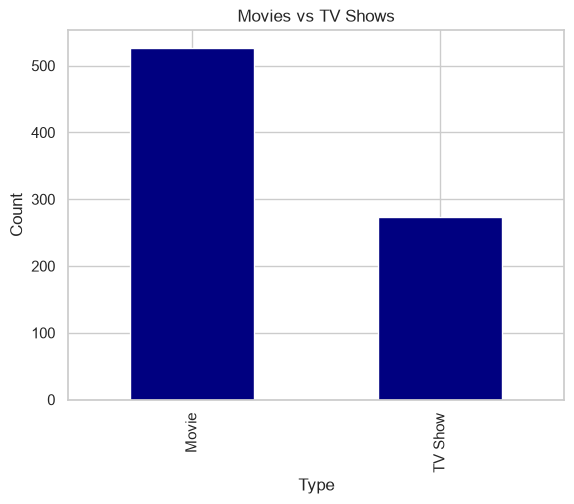

In [42]:
total_titles=len(titles)
print(f'Number of titles is {total_titles}')
types=titles['type'].value_counts()


types.plot(kind='bar', color='navy')
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

**Findings:** The total number of titles in catalog is 800. The catalog of movies is twice bigger than TV shows' catalog. 

#### Q2 — Catalog growth by year

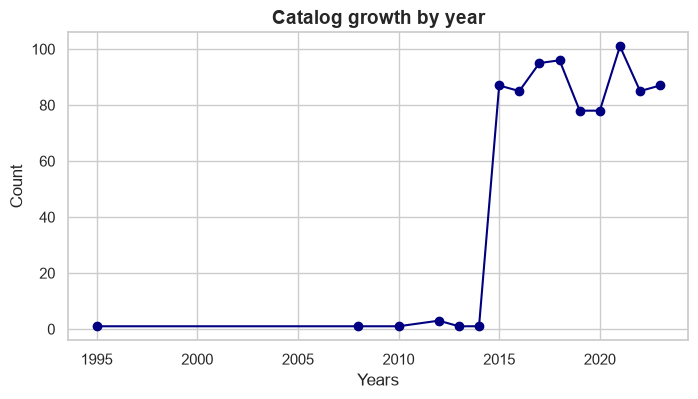

In [43]:
titles['year_added']=titles['date_added'].dt.year
catalog_growth = titles['year_added'].value_counts().sort_index()
catalog_growth.plot(kind='line',marker='o',figsize=(8,4),color='navy')
plt.title('Catalog growth by year', fontsize=14, fontweight='bold')
plt.xlabel('Years')
plt.ylabel('Count')
plt.grid(True)
plt.show()

**Findings:** There is a signinficant increase in 2014 in catalog growth

#### Q3 — Most common content ratings

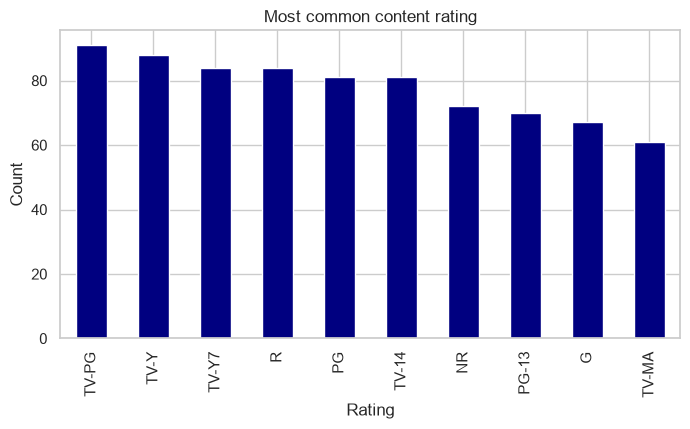

In [44]:
filtered_df = titles[titles['content_rating'] != 'unknown']
content_rating = filtered_df['content_rating'].value_counts()
content_rating.plot(kind='bar', color='navy',figsize=(8,4))
plt.title('Most common content rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(True)
plt.show()

**Findings:** TV-PG is the most common content rating

#### Q4 — Top 10 producing countries

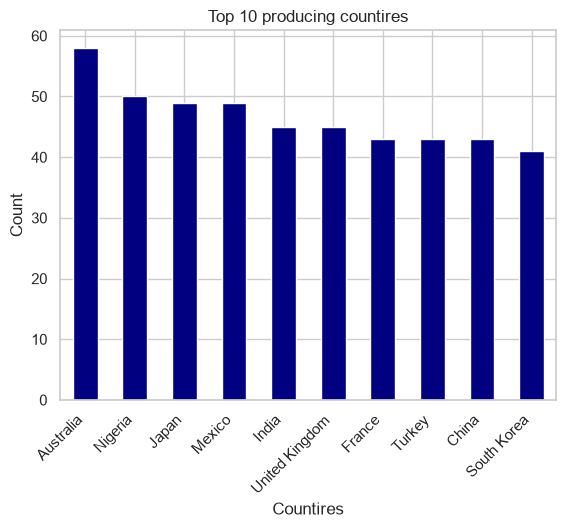

In [45]:
top_10_countries = titles[titles['country'] != 'unknown']['country'].value_counts().head(10)
top_10_countries.plot(kind='bar',color='navy')
plt.title('Top 10 producing countires')
plt.xlabel('Countires')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

**Findings:** Australia, Nigeria and Japan are the top producing countries

### 🎭 Section B — Genres & Cast

#### Q5 — Top 10 most common genres

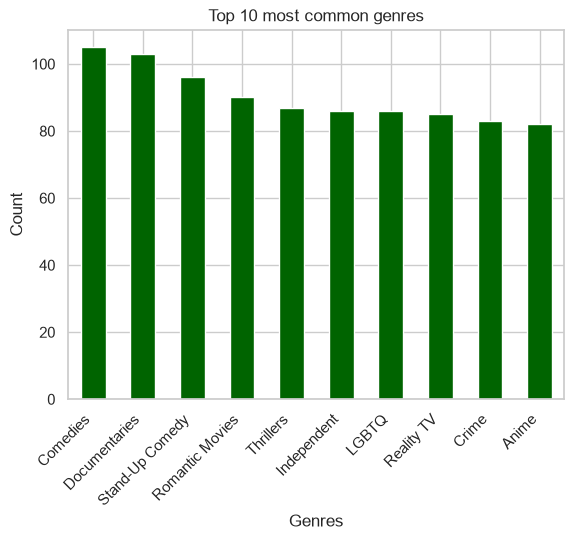

In [46]:
top_genres = genres['genre'].value_counts().head(10)
top_genres.plot(kind='bar',color='darkgreen')
plt.title('Top 10 most common genres')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

**Findings:** Comedies, Documentaries and Stand-Up Comedy are the top 3 genres in the catalog.

#### Q6 — Genres by type (Movie vs TV Show)

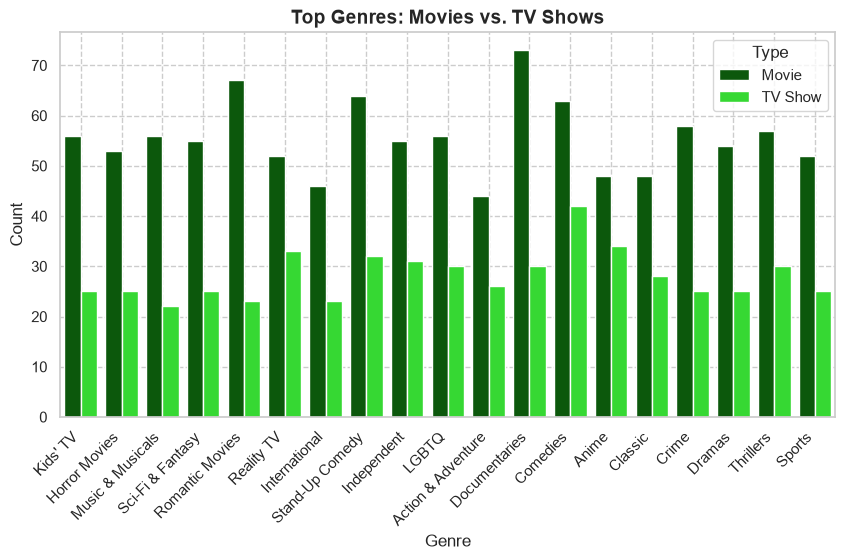

In [47]:
genres_type = titles.merge(genres,on='title_id',how='left')

plt.figure(figsize=(10, 5))
sns.countplot(
    data=genres_type, 
    x='genre', 
    hue='type',
    palette=['darkgreen', "#1CF318"]
)

plt.title('Top Genres: Movies vs. TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.legend(title='Type')
plt.grid(True, linestyle='--')
plt.xticks(rotation=45, ha='right')

plt.show()




**Findings:** Documentaries and Romantic Movies are the most common genres in the movie library, while Comedies and Independent titles lead the TV show category.

#### Q7 — Top 10 most frequent actors

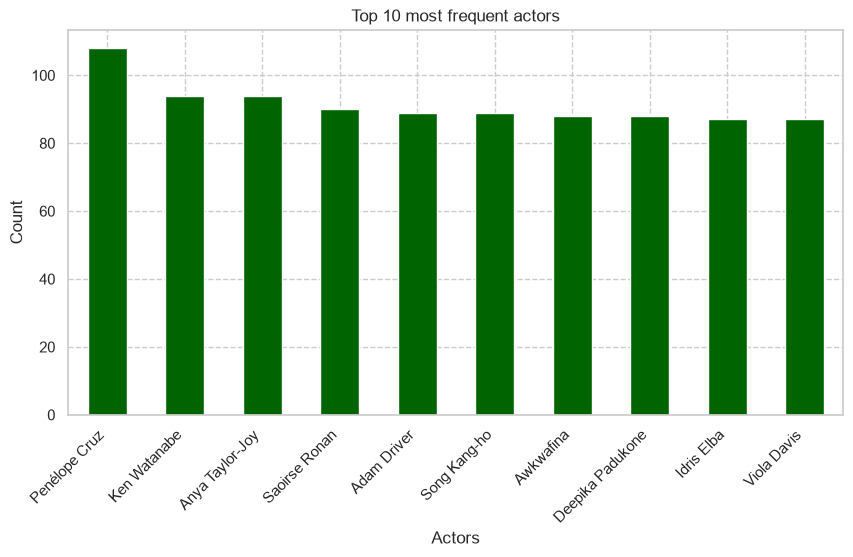

In [48]:
titles_cast= titles.merge(cast,on='title_id',how='left')
top_actors = titles_cast['actor_name'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_actors.plot(kind='bar',color='darkgreen')
plt.title('Top 10 most frequent actors')
plt.xlabel('Actors')
plt.ylabel('Count')
plt.grid(True,linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.show()

**Findings:** Penelope Cruz is the most frequent actor

#### Q8 — Lead vs Supporting actor frequency

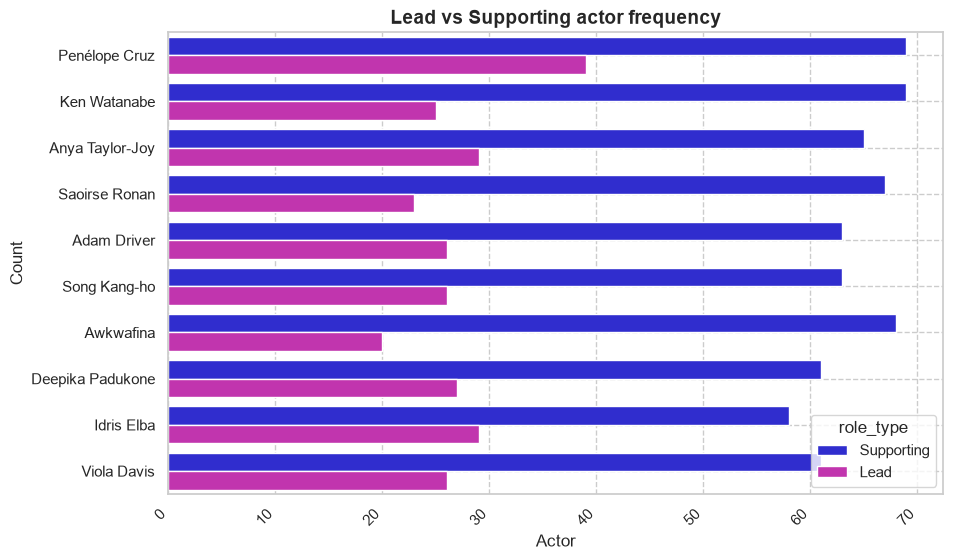

In [49]:
top10_names = titles_cast['actor_name'].value_counts().head(10).index
only10_actors=titles_cast[titles_cast['actor_name'].isin(top10_names)]
plt.figure(figsize=(10, 6))
sns.countplot(
    data=only10_actors, 
    y='actor_name', 
    hue='role_type',
    order=top10_names,
    palette=["#1612e9", "#d81ebf"]
)

plt.title('Lead vs Supporting actor frequency', fontsize=14, fontweight='bold')
plt.xlabel('Actor')
plt.ylabel('Count')
plt.legend(title='role_type')
plt.grid(True, linestyle='--')
plt.xticks(rotation=45, ha='right')

plt.show()


**Findings:** Penelope Cruz and Ken Watanabe have the same number of supporting roles.  Penelope Cruz is the 1st by leading roles

### ⭐ Section C — Ratings Analysis

#### Q9 — Overall average rating across all titles

In [50]:
average_rating = ratings['rating'].mean().round(2)
print(f'Overall average rating is {average_rating}')

Overall average rating is 3.64


**Findings:** Overall average rating is 3.64

#### Q10 — Top 10 highest-rated titles (min 20 ratings)

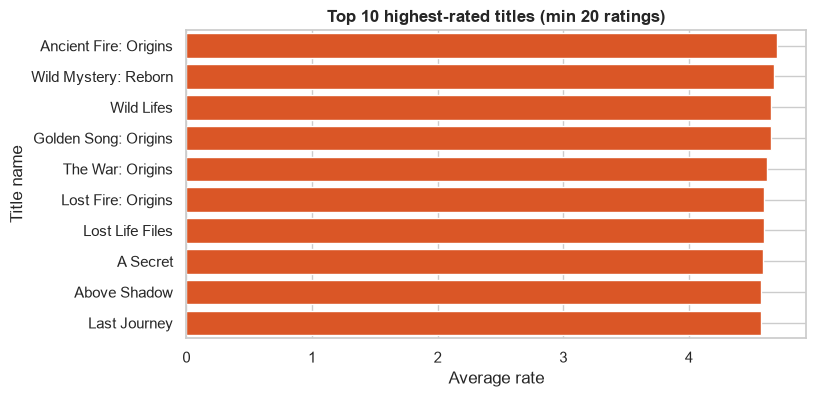

In [51]:
ratings_titles = ratings.merge(titles,on='title_id',how='left')
rating_all = ratings_titles.groupby(['title_id','title']).agg(
    average_rate = ('rating','mean'),
    rating_count = ('rating','count')
)

ratings_min20 = rating_all[rating_all['rating_count'] >=20]
top10_ratings = ratings_min20.sort_values(by='average_rate', ascending = False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(
    data=top10_ratings,
    x='average_rate',
	y='title',
    color="#F84808"
     
)

plt.title('Top 10 highest-rated titles (min 20 ratings)',fontweight='bold')
plt.xlabel('Average rate')
plt.ylabel('Title name')
plt.grid(True)
plt.show()



**Findings:** Ancent Fire: Origins is the top rated movie. The rest of the movies/shows dont have a big difference in rating.

#### Q11 — Average rating per genre

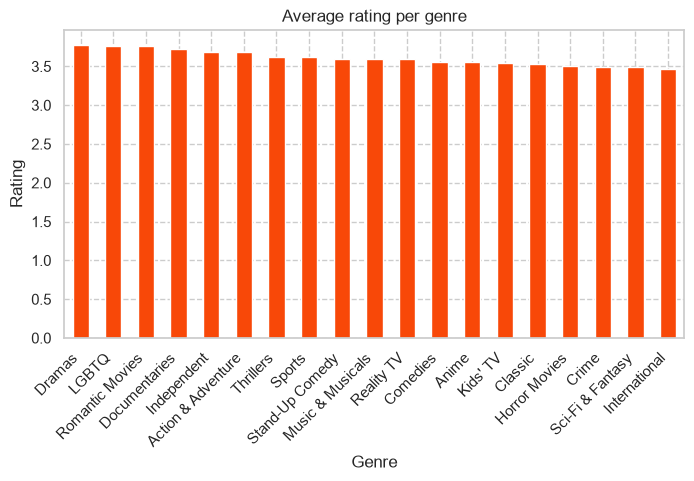

In [52]:
ratings_titles_genres=ratings_titles.merge(genres,on='title_id',how='left')
average_rating_genre=ratings_titles_genres.groupby('genre')['rating'].mean().round(2)
rating_sorting = average_rating_genre.sort_values(ascending=False)
plt.figure(figsize=(8,4))
rating_sorting.plot(kind='bar',color="#F84808")
plt.title('Average rating per genre')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.grid(True,linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.show()

**Findings:** Dramas, LGBTQ and Romatnic Movies are the highest rated genres

#### Q12 — Do Movies or TV Shows get higher ratings?

In [53]:
types_ratings = ratings_titles.groupby('type')['rating'].mean()
print(types_ratings)

type
Movie      3.658957
TV Show    3.612219
Name: rating, dtype: float64


**Findings:** Movies get slighlty higher ratings than TV shows 

#### Q13 — Release year vs average rating

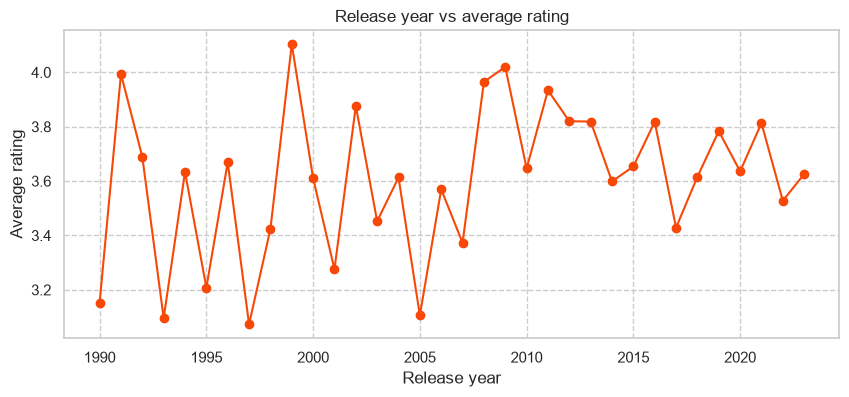

In [54]:
release_rating = ratings_titles.groupby('release_year')['rating'].mean()
plt.figure(figsize=(10,4))
release_rating.plot(kind='line',marker='o', color="#F84808")
plt.title('Release year vs average rating')
plt.xlabel('Release year')
plt.ylabel('Average rating')
plt.grid(True,linestyle='--')

plt.show()

**Findings:** Its seen that average rating wasnt stable across the release years. The highest ratings got titles released in 1991,1999 and 2009. The lowest average rating was noted for titles released in 1993,1997 and 2005. However, combined with our finding in Q17 that ratings do not drive views, its recommended avoiding year-based assumptions in content purchasing.

### 📈 Section D — Viewership Analysis

#### Q14 — Top 10 most-viewed titles

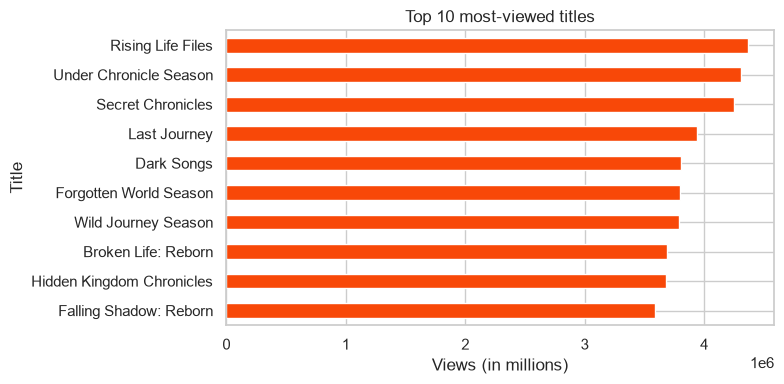

In [55]:
titles_view = titles.merge(viewership,on='title_id',how='left')
most_viewed = titles_view.groupby('title')['views'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
most_viewed.plot(kind='barh',color="#F84808")
plt.title('Top 10 most-viewed titles')
plt.xlabel('Views (in millions)')
plt.ylabel('Title')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

**Findings:** 'Raising Life Files' is the most viewed title

#### Q15 — Total views per genre

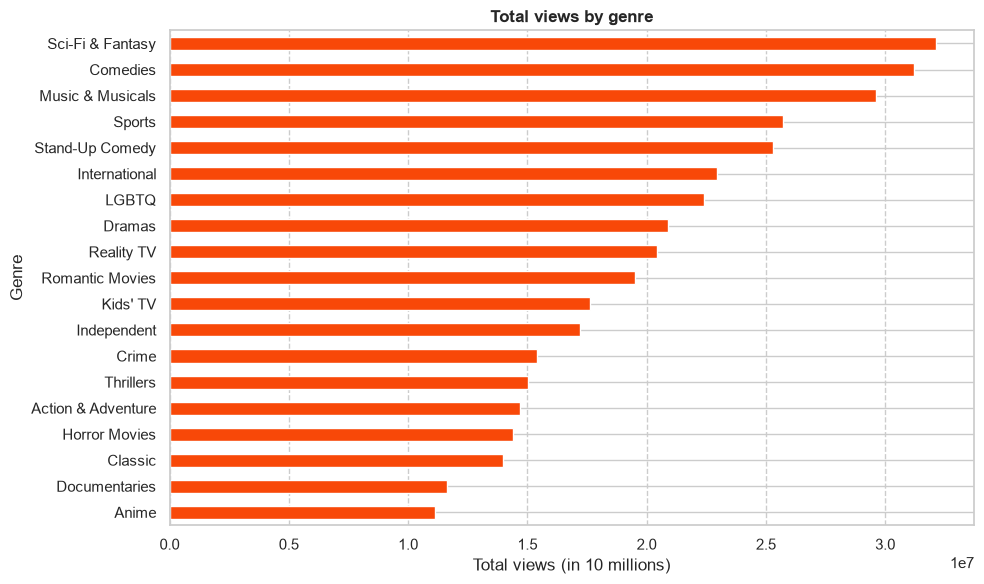

In [56]:
views_genres_df = viewership.merge(genres,on='title_id',how='left')
views_genres2 = views_genres_df.groupby('genre')['views'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6)) 

views_genres2.plot(kind='barh', color="#F84808")

plt.title('Total views by genre',fontweight='bold')
plt.xlabel('Total views (in 10 millions)')
plt.ylabel('Genre')
plt.gca().invert_yaxis()

plt.grid(True, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

**Findings:** Sci-Fi&Fantasy, Comedies and Music&Musicals are the most viewed genres

#### Q16 — Monthly viewership trend across the platform

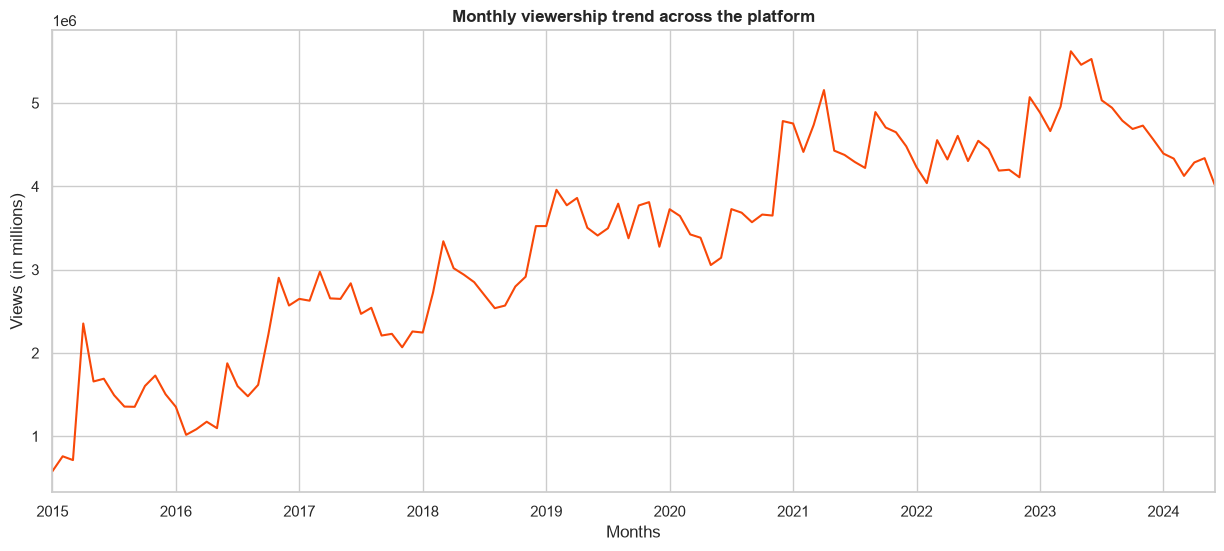

In [57]:
monthly_view = views_genres_df.groupby('month')['views'].sum()

plt.figure(figsize=(15,6))
monthly_view.plot(kind='line', color="#F84808")

plt.title('Monthly viewership trend across the platform',fontweight='bold')
plt.xlabel('Months')
plt.ylabel('Views (in millions)')
plt.grid(True)
plt.show()

In [58]:
#additional analysis of average views per title according to their type
total_views_by_type = titles_view.groupby('type')['views'].sum()
unique_titles_by_type = titles_view.groupby('type')['title'].nunique()
avg_views_per_title = total_views_by_type / unique_titles_by_type

print("Average Views Per Individual Title:")
print(avg_views_per_title)

Average Views Per Individual Title:
type
Movie      246893.375262
TV Show    259579.776471
dtype: float64


**Findings:** 
1. The trend goes up usually towards end of the year when people spend more time at home and when holidays season starts. 
2. The trend slows down during the mid year since its summer period and people usually spend time outdoors.  
3. Additional analysis has shown that TV shows outperform movies on a per-title basis. It means that even though Movies' catalog is twice as bigger than TV shows', still viewers engage with TV shows even more than with movies. 
As per that finding, TV shows catalog can be expanded and could imrpove customers' engagement. This statement also confirms the finding from Q12 where Movies got slightly higher ratings than TV shows

#### Q17 — Are highly-rated titles the most viewed? (correlation)

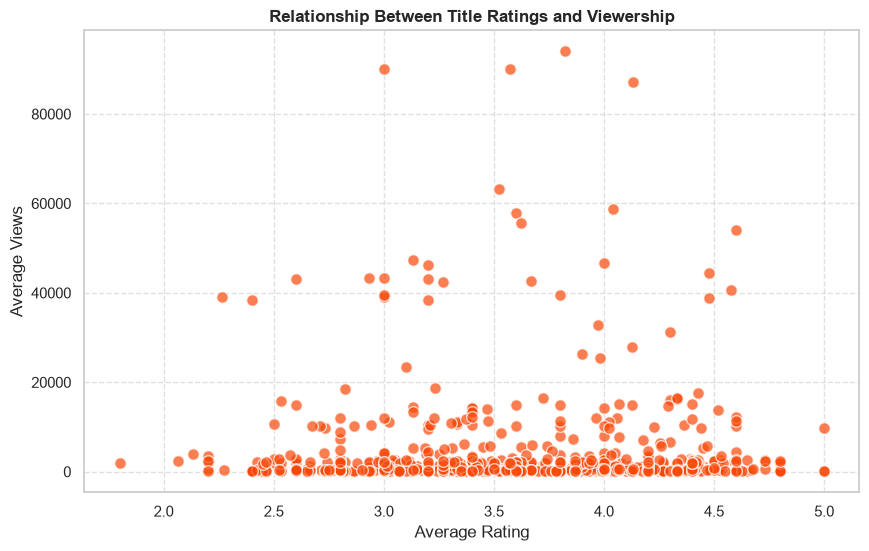

In [59]:
avg_rating = ratings_titles.groupby('title')['rating'].mean()
avr_views = titles_view.groupby('title')['views'].mean()

comparison_df = pd.DataFrame({
    'rating': avg_rating,
    'views': avr_views
}).dropna() 

plt.figure(figsize=(10, 6))
plt.scatter(
    comparison_df['rating'], 
    comparison_df['views'], 
    color="#F84808", 
    alpha=0.7, 
    edgecolors='w', 
    s=70
)

plt.title('Relationship Between Title Ratings and Viewership', fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Average Views')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Findings:** The chart shows very little correlation between titles rating and viewership which means that we should focus on promoting popular genres rather than relying on titles ratings alone to attract viewers. 

## 5. 🎯 Final Recommendations

**1.** 
Biggest and the most expensive releases should be scheduled for the final months of the year. Its recommended avoid dropping the biggest releases during summer months. 
Reasoning: As per monthly views chart the trend goes up usually towards end of the year when people spend more time at home and when holidays season starts. The trend slows down during the mid year since its summer period and people usually spend time outdoors. 
It supports Q16.


**2.** 
Budget allocation should be concentrated on titles from Sci-Fi&Fantasy genre:
The data shows that Sci-Fi & Fantasy is the most watched category on the platform. Because it brings in the highest number of views, it acts as our main anchor. 
Comedies and Music & Musicals should be used as bridge content: Comedies are our second most popular genre, and Music & Musicals take third place. Instead of dropping all our best movies at once, we should use comedies and musicals to keep people entertained and engaged during the quiet weeks between big Sci-Fi releases.
The Reason Behind This Strategy:
Sci-Fi&Fantasy is the most viewed genre which means that its the main retention genre. Comedies genre takes the 2nd place, Music&Musicals is the 3d. By backing our top three genres with a smart release schedule, we ensure the platform always has something popular to watch all year round. 
Q15 supports the answer.


**3.** The platform should strategically expand its TV show library since the audience demand for TV content is high relative to its small catalog footprint, Buying or making more TV shows will keep viewers happy and boost engagement without needing to grow the movie library even more.
The Reason Behind This Strategy:
Even though the TV shows’ catalog is twice smaller then Movies’ catalog, 
 Individual TV shows actually achieve higher average views (~260K) compared to movies (~247K) (represented in Q16).
TV shows maintain nearly identical average ratings to movies (3.61 vs. 3.66) (represented in Q12).

